# Dataset 1 — données défaut

Ce notebook charge le modèle appris dans dataset0 et l’applique aux features de dataset1.

In [9]:
import os
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import tsfel
import time
import numpy as np

# Chemins robustes : le notebook peut être ouvert depuis ST4/, dataset0/ ou dataset1/
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name in ["dataset0", "dataset1"] else CURRENT_DIR
DATASET0_DIR = PROJECT_DIR / "dataset0"
DATASET1_DIR = PROJECT_DIR / "dataset1"

print("PROJECT_DIR  =", PROJECT_DIR)
print("DATASET0_DIR =", DATASET0_DIR)
print("DATASET1_DIR =", DATASET1_DIR)


PROJECT_DIR  = c:\Users\user\Documents\ST4
DATASET0_DIR = c:\Users\user\Documents\ST4\dataset0
DATASET1_DIR = c:\Users\user\Documents\ST4\dataset1


In [10]:
# Chargement du modèle appris dans dataset0
model_path = DATASET0_DIR / "kde_model_dataset0.pkl"

with open(model_path, "rb") as f:
    model_artifacts = pickle.load(f)

feature_columns = model_artifacts["feature_columns"]
feature_medians = model_artifacts["feature_medians"]
scaler = model_artifacts["scaler"]
pca = model_artifacts["pca"]
kde = model_artifacts["kde"]
threshold = model_artifacts["threshold"]
alpha = model_artifacts.get("alpha", None)
bandwidth = model_artifacts.get("bandwidth", None)
X_kde_sample = model_artifacts.get("X_kde_sample")

print("Modèle chargé depuis :", model_path)
print("Nombre de features attendues :", len(feature_columns))
print("Seuil KDE fenêtre :", threshold)
print("Alpha :", alpha)
print("Bandwidth :", bandwidth)

Modèle chargé depuis : c:\Users\user\Documents\ST4\dataset0\kde_model_dataset0.pkl
Nombre de features attendues : 246
Seuil KDE fenêtre : -14.004802100248469
Alpha : 0.05
Bandwidth : 2.5


In [11]:
fileEF_default = str(DATASET1_DIR / "pdfFeatures1.pkl")
pdfEF_default = pd.read_pickle(fileEF_default)

***Application du modèle dataset0 sur dataset1***

In [13]:
# Même cleaning que dataset0, mais avec les colonnes apprises dans dataset0
df_default = pdfEF_default.copy()

X_default = df_default.drop(columns=["i"], errors="ignore")
X_default = X_default.apply(pd.to_numeric, errors="coerce")
X_default = X_default.replace([np.inf, -np.inf], np.nan)

# On force exactement les mêmes colonnes que dataset0
X_default = X_default.reindex(columns=feature_columns)

# Même logique de remplissage : médianes apprises sur dataset0
X_default = X_default.fillna(feature_medians)

print("Shape défaut après alignement :", X_default.shape)
print("Nombre de NaN restants :", X_default.isna().sum().sum())

Shape défaut après alignement : (9983, 246)
Nombre de NaN restants : 0


In [22]:
# Projection des défauts avec le scaler et la PCA appris sur dataset0
X_default_scaled = scaler.transform(X_default)
X_default_pca = pca.transform(X_default_scaled)

# Score KDE : plus le score est faible, plus la fenêtre est anormale
kde_score_default = kde.score_samples(X_default_pca)

# Détection fenêtre par fenêtre avec le seuil appris sur dataset0
outlier_default = kde_score_default < threshold

df_default_result = df_default.copy()
df_default_result["PCA1"] = X_default_pca[:, 0]
df_default_result["PCA2"] = X_default_pca[:, 1]
df_default_result["kde_score"] = kde_score_default
df_default_result["outlier"] = outlier_default
df_default_result["is_normal"] = ~outlier_default
df_default_result["anomaly_score"] = -kde_score_default

print("Nombre de fenêtres défaut :", len(df_default_result))
print("Fenêtres détectées anormales :", df_default_result["outlier"].sum())
print("Pourcentage :", round(df_default_result["outlier"].mean() * 100, 2), "%")


Nombre de fenêtres défaut : 9983
Fenêtres détectées anormales : 1154
Pourcentage : 11.56 %


In [ ]:
# Résumé par identifiant
summary_default = (
    df_default_result
    .groupby("i")
    .agg(
        nb_windows=("outlier", "size"),
        nb_windows_anormales=("outlier", "sum"),
        pct_windows_anormales=("outlier", lambda x: 100 * x.mean()),
        kde_score_mean=("kde_score", "mean"),
        kde_score_min=("kde_score", "min"),
        anomaly_score_mean=("anomaly_score", "mean"),
        anomaly_score_max=("anomaly_score", "max"),
    )
    .reset_index()
)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,anomaly_score_mean,anomaly_score_max
35,W7U2UIMDO,202,42,20.792079,-24.769689,-1758.252459,24.769689,1758.252459
7,AQ86JGMKW,232,43,18.534483,-739.198254,-120339.881998,739.198254,120339.881998
24,QRJ024QY0,177,31,17.514124,-58.244803,-8123.780060,58.244803,8123.780060
17,KIQ82T2TF,142,24,16.901408,-16.196940,-690.093168,16.196940,690.093168
34,VKKP5AEBV,239,36,15.062762,-10.198601,-139.435389,10.198601,139.435389
32,VB8ITSU4T,189,28,14.814815,-16.420555,-1243.187853,16.420555,1243.187853
37,Y23NPM4YM,203,30,14.778325,-12.153761,-593.431006,12.153761,593.431006
27,S012VTJSD,309,45,14.563107,-19.342606,-2797.617628,19.342606,2797.617628
19,N5PJJE2ET,261,38,14.559387,-18.913524,-1922.100054,18.913524,1922.100054
20,NYHQFSS36,208,29,13.942308,-28.267063,-2628.852680,28.267063,2628.852680


In [ ]:
# Seuils au niveau identifiant
# Un identifiant est détecté défaut si au moins X % de ses fenêtres sont outliers

seuils_id = [5]

for seuil in seuils_id:
    summary_default[f"id_detected_faulty_{seuil}pct"] = (
        summary_default["pct_windows_anormales"] >= seuil
    )

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,id_detected_faulty_5pct
0,2U2HN8U8D,323,28,8.668731,-7.686036,-108.155947,True
1,3A2AKKKHI,314,26,8.280255,-14.739004,-1478.511800,True
2,48WK1UQQO,329,31,9.422492,-8.193824,-159.737789,True
3,6QXC4QTK2,203,24,11.822660,-8.578248,-167.075363,True
4,87UUY7547,242,23,9.504132,-8.815505,-178.048009,True
5,8IWYZ3WFE,187,17,9.090909,-7.041639,-51.411026,True
6,9DI4D2S36,162,22,13.580247,-10.082841,-156.295253,True
7,AQ86JGMKW,232,43,18.534483,-739.198254,-120339.881998,True
8,AZTVA5ZWX,259,31,11.969112,-10.716900,-499.208337,True
9,D3R3JJGIL,314,28,8.917197,-10.494088,-902.349804,True


In [36]:
from sklearn.model_selection import train_test_split

# Split dataset1 par identifiant
# Objectif : calibrer un seuil défaut 1 sur train, puis vérifier sur test

ids_fault1 = summary_default["i"].unique()

ids_fault1_train, ids_fault1_test = train_test_split(
    ids_fault1,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

summary_fault1_train = summary_default[
    summary_default["i"].isin(ids_fault1_train)
].copy()

summary_fault1_test = summary_default[
    summary_default["i"].isin(ids_fault1_test)
].copy()

print("Nombre identifiants défaut 1 train :", len(summary_fault1_train))
print("Nombre identifiants défaut 1 test  :", len(summary_fault1_test))

summary_fault1_train.head()

Nombre identifiants défaut 1 train : 32
Nombre identifiants défaut 1 test  : 8


,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,anomaly_score_mean,anomaly_score_max,id_detected_faulty_5pct,id_detected_faulty
0,2U2HN8U8D,323,28,8.668731,-7.686036,-108.155947,7.686036,108.155947,True,True
1,3A2AKKKHI,314,26,8.280255,-14.739004,-1478.511800,14.739004,1478.511800,True,True
2,48WK1UQQO,329,31,9.422492,-8.193824,-159.737789,8.193824,159.737789,True,True
3,6QXC4QTK2,203,24,11.822660,-8.578248,-167.075363,8.578248,167.075363,True,True
5,8IWYZ3WFE,187,17,9.090909,-7.041639,-51.411026,7.041639,51.411026,True,True


In [37]:
# Calibration du seuil identifiant défaut 1

alpha_fault1 = 0.05

seuil_id_final = np.quantile(
    summary_fault1_train["pct_windows_anormales"],
    alpha_fault1
)

print("Seuil identifiant défaut 1 appris sur dataset1 train :", seuil_id_final, "%")

Seuil identifiant défaut 1 appris sur dataset1 train : 8.370559094125973 %


In [38]:
# Évaluation sur train et test dataset1

summary_fault1_train["id_detected_faulty"] = (
    summary_fault1_train["pct_windows_anormales"] >= seuil_id_final
)

summary_fault1_test["id_detected_faulty"] = (
    summary_fault1_test["pct_windows_anormales"] >= seuil_id_final
)

print("Détection défaut 1 sur train :")
print("  Identifiants détectés :", summary_fault1_train["id_detected_faulty"].sum())
print("  Total :", len(summary_fault1_train))
print("  Pourcentage :", round(100 * summary_fault1_train["id_detected_faulty"].mean(), 2), "%")

print()

print("Détection défaut 1 sur test :")
print("  Identifiants détectés :", summary_fault1_test["id_detected_faulty"].sum())
print("  Total :", len(summary_fault1_test))
print("  Pourcentage :", round(100 * summary_fault1_test["id_detected_faulty"].mean(), 2), "%")

Détection défaut 1 sur train :
  Identifiants détectés : 30
  Total : 32
  Pourcentage : 93.75 %

Détection défaut 1 sur test :
  Identifiants détectés : 7
  Total : 8
  Pourcentage : 87.5 %


In [40]:
summary_default["id_detected_faulty"] = (
    summary_default["pct_windows_anormales"] >= seuil_id_final
)

summary_default.sort_values(
    by="pct_windows_anormales",
    ascending=True
).head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,anomaly_score_mean,anomaly_score_max,id_detected_faulty_5pct,id_detected_faulty
12,FKSY1Y1K5,274,14,5.109489,-6.598825,-42.857167,6.598825,42.857167,True,False
38,YDNKYY8MS,266,22,8.270677,-7.049767,-45.597622,7.049767,45.597622,True,False
1,3A2AKKKHI,314,26,8.280255,-14.739004,-1478.511800,14.739004,1478.511800,True,False
18,KOTSIR47O,225,19,8.444444,-7.745943,-103.263902,7.745943,103.263902,True,True
16,GF0FTT8Z7,302,26,8.609272,-7.537230,-75.802263,7.537230,75.802263,True,True
0,2U2HN8U8D,323,28,8.668731,-7.686036,-108.155947,7.686036,108.155947,True,True
9,D3R3JJGIL,314,28,8.917197,-10.494088,-902.349804,10.494088,902.349804,True,True
26,RZM0XIF8G,199,18,9.045226,-13.671028,-960.531476,13.671028,960.531476,True,True
5,8IWYZ3WFE,187,17,9.090909,-7.041639,-51.411026,7.041639,51.411026,True,True
25,RJ9RSGP8N,361,33,9.141274,-9.584172,-751.182610,9.584172,751.182610,True,True


---
### Visualisation PCA dataset1

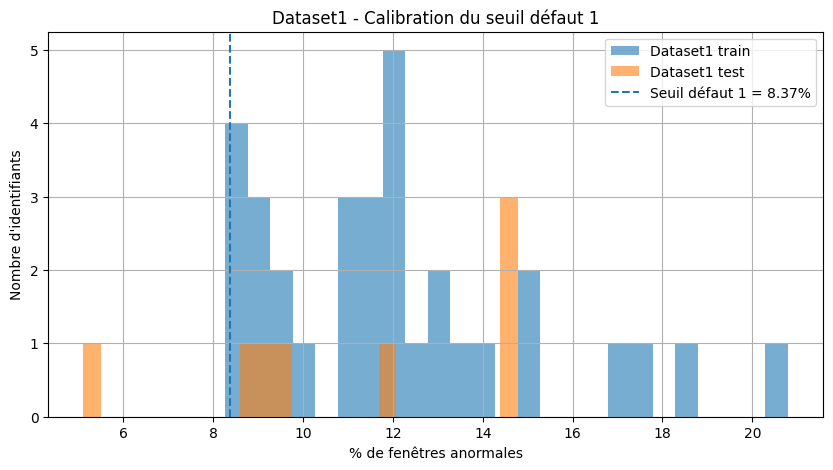

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    summary_fault1_train["pct_windows_anormales"],
    bins=25,
    alpha=0.6,
    label="Dataset1 train"
)

plt.hist(
    summary_fault1_test["pct_windows_anormales"],
    bins=25,
    alpha=0.6,
    label="Dataset1 test"
)

plt.axvline(
    seuil_id_final,
    linestyle="--",
    label=f"Seuil défaut 1 = {seuil_id_final:.2f}%"
)

plt.xlabel("% de fenêtres anormales")
plt.ylabel("Nombre d'identifiants")
plt.title("Dataset1 - Calibration du seuil défaut 1")
plt.legend()
plt.grid()
plt.show()

In [43]:
# Sauvegarde des seuils appris sur dataset1 pour réutilisation dans dataset2

fault1_thresholds = {
    "seuil_id_final": seuil_id_final,
    "alpha_fault1": alpha_fault1,
    "metric": "pct_windows_anormales",
    "description": "Seuil identifiant défaut 1 appris sur dataset1 à partir du % de fenêtres anormales selon le modèle normal dataset0",
}

threshold_path = DATASET1_DIR / "thresholds_fault1_dataset1.pkl"

with open(threshold_path, "wb") as f:
    pickle.dump(fault1_thresholds, f)

print("Seuils dataset1 sauvegardés dans :", threshold_path)
print("Seuil identifiant défaut 1 :", seuil_id_final, "%")

Seuils dataset1 sauvegardés dans : c:\Users\user\Documents\ST4\dataset1\thresholds_fault1_dataset1.pkl
Seuil identifiant défaut 1 : 8.370559094125973 %
